<a href="https://colab.research.google.com/github/raaghuno18-spec/Titanic/blob/main/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 02 — Machine Learning Model: Titanic Survival Prediction
**Pluto Academy AI & ML Internship**

**Problem Statement:** Build, train, and evaluate a machine learning model that predicts
whether a Titanic passenger survived. Compare 3 different ML algorithms and identify
the best performer.

**Dataset:** [Titanic — Survival Prediction](https://www.kaggle.com/c/titanic) (Kaggle)

> Download `train.csv` from the Kaggle competition page and place it in the same folder
> as this notebook (or upload it if running on Colab).


## Step 1 — Load, Explore & Preprocess

In [3]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('train.csv')

print("Shape:", df.shape)
print()
print(df.info())
print()
print("Missing values:\n", df.isnull().sum())
print()
df.head()


Shape: (891, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin        

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Preprocessing decisions:**
- `PassengerId`, `Name`, `Ticket` — dropped (identifiers / high-cardinality text, no direct predictive value without heavy NLP feature engineering)
- `Cabin` — dropped (over 77% missing, not reliably imputable)
- `Age` — filled with median (robust to outliers, avoids reducing dataset size)
- `Embarked` — filled with mode (only 2 missing values)
- `Sex`, `Embarked` — encoded numerically since models require numeric input


In [4]:
# Drop columns that don't help prediction
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Encode categorical variables
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (712, 8)
Test shape: (179, 8)


## Step 2 — Feature Engineering

Survived      1.000000
Sex           0.543351
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
Embarked_Q    0.003650
SibSp        -0.035322
Age          -0.064910
Embarked_S   -0.149683
Pclass       -0.338481
Name: Survived, dtype: float64


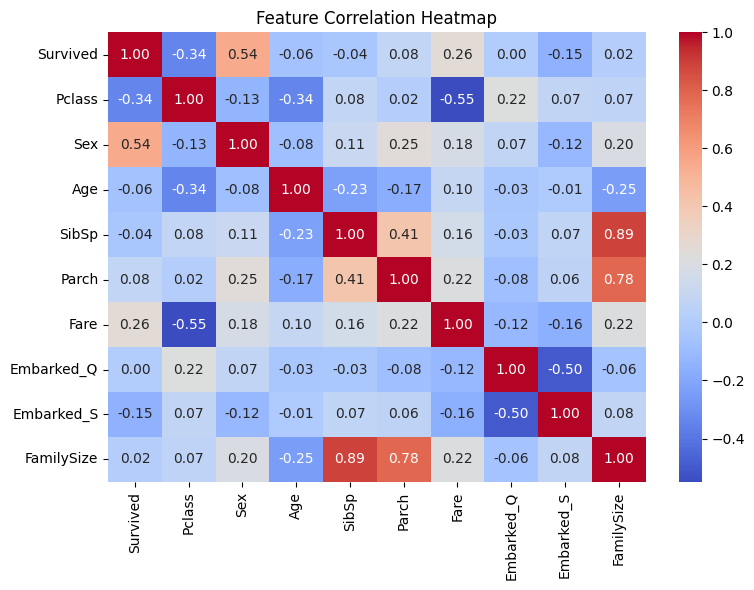

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional engineered feature: family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Correlation with target
corr = df.corr(numeric_only=True)['Survived'].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


**Feature selection notes:** *(write your own observations here based on the heatmap output —
e.g. which features correlate most strongly with `Survived`, and why that makes sense historically)*


## Step 3 — Train 3 Different Models

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# KNN and Logistic Regression benefit from scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)  # tree models don't require scaling

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

print("All 3 models trained.")


All 3 models trained.


## Step 4 — Evaluate & Compare All Models

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': (log_reg, X_test_scaled),
    'Random Forest': (rf, X_test),
    'KNN': (knn, X_test_scaled)
}

results = []
for name, (model, X_te) in models.items():
    preds = model.predict(X_te)
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4),
        'F1': round(f1_score(y_test, preds), 4)
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1
0,KNN,0.8156,0.8000,0.6957,0.7442
1,Random Forest,0.8101,0.7869,0.6957,0.7385
2,Logistic Regression,0.8045,0.7931,0.6667,0.7244


**Submission tip:** screenshot the comparison table above — it's a required submission item.

## Step 5 — Best Model Analysis & Conclusion

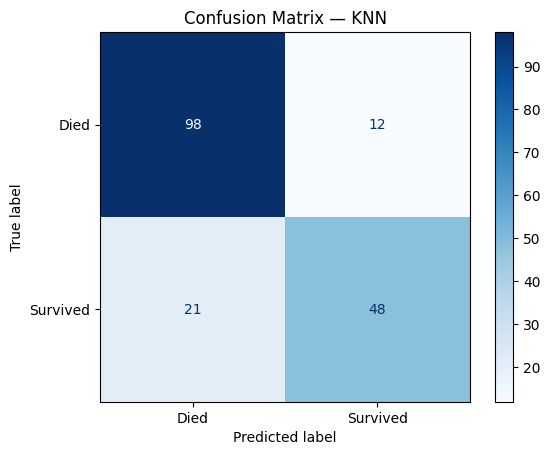

Best model: KNN
                 Model  Accuracy  Precision  Recall      F1
0                  KNN    0.8156     0.8000  0.6957  0.7442
1        Random Forest    0.8101     0.7869  0.6957  0.7385
2  Logistic Regression    0.8045     0.7931  0.6667  0.7244


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model_name = results_df.iloc[0]['Model']
best_model, X_te = models[best_model_name]
best_preds = best_model.predict(X_te)

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

print(f"Best model: {best_model_name}")
print(results_df)


### 5-line Conclusion *(write this yourself, in your own words)*

Cover:
1. Which model performed best, and by what margin (cite your actual F1/Accuracy numbers).
2. Why that model type likely suits this dataset (e.g. Random Forest captures non-linear
   feature interactions like Pclass × Sex without manual feature crosses).
3. Which single feature seemed most influential, and whether that matches historical
   context (e.g. "women and children first").
4. One limitation of this analysis (e.g. small dataset size, information lost by dropping `Cabin`).
5. What you'd try next to improve the model (e.g. hyperparameter tuning, more engineered features).
